In [13]:
## Simple Graph

In [12]:
from typing import TypedDict

In [2]:
class PortfolioState(TypedDict):
    amount_usd:float
    total_usd:float
    amount_inr:float

In [17]:
def cal_total(state:PortfolioState) -> PortfolioState:
    state['total_usd'] = state['amount_usd'] * 1.08 #Return rate of 8%
    return state

def cal_inr(state:PortfolioState) -> PortfolioState:
    state['amount_inr'] = state['total_usd'] * 85 #exchange rate
    return state

In [18]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(PortfolioState)
builder.add_node("cal_total_node", cal_total)
builder.add_node("cal_inr_node", cal_inr)

builder.add_edge(START, "cal_total_node")
builder.add_edge("cal_total_node", "cal_inr_node")
builder.add_edge("cal_inr_node", END)

graph = builder.compile()

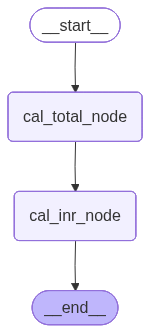

In [19]:
from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))

In [20]:
graph.invoke({"amount_usd":1000})

{'amount_usd': 1000, 'total_usd': 1080.0}

In [21]:
## Graph With Condition

In [22]:
from typing import TypedDict, Literal

In [23]:
class PortfolioState(TypedDict):
    amount_usd:float
    total_usd:float
    target_currency: Literal["INR", "EUR"]
    total:float

In [26]:
def cal_total(state:PortfolioState) -> PortfolioState:
    state['total_usd'] = state['amount_usd'] * 1.08 #Return rate of 8%
    return state

def cal_inr(state:PortfolioState) -> PortfolioState:
    state['total'] = state['total_usd'] * 85 #exchange rate
    return state

def cal_eur(state:PortfolioState) -> PortfolioState:
    state['total'] = state['total_usd'] * 0.9 #exchange rate
    return state

def choose_conversion(state:PortfolioState) -> str:
    return state['target_currency']

In [27]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(PortfolioState)
builder.add_node("cal_total_node", cal_total)
builder.add_node("cal_inr_node", cal_inr)
builder.add_node("cal_eur_node", cal_eur)

builder.add_edge(START, "cal_total_node")
builder.add_conditional_edges(
    "cal_total_node",
    choose_conversion,
    {
        "INR": "cal_inr_node",
        "EUR": "cal_eur_node"
    }
    )
builder.add_edge(["cal_inr_node","cal_eur_node"], END)

graph = builder.compile()

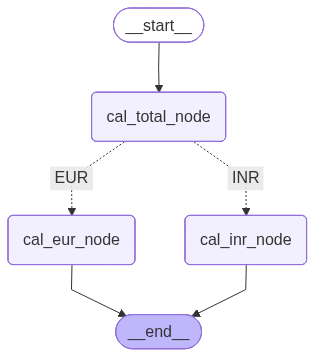

In [28]:
from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))

In [32]:
graph.invoke({"amount_usd":1000, "target_currency":"INR"})

{'amount_usd': 1000,
 'total_usd': 1080.0,
 'target_currency': 'INR',
 'total': 91800.0}